In [1]:
# LIBRARIES 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar


In [2]:
# LOAD DATASET 

df = pd.read_csv(r'C:\Users\smmblz\Downloads\Unemployment in India.csv')
df.columns = df.columns.str.strip()
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")


Dataset Shape: 768 rows, 7 columns



In [3]:
# BASIC INSPECTION

print("Dataset overview:")
print(df.head())

Dataset overview:
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  


In [4]:
# DATA QUALITY

print("\nMissing Values Count:")
print(df.isnull().sum().max())


Missing Values Count:
28


In [5]:
# DATA CLEANING & FEATURE ENGINEERING

df = df.dropna().reset_index(drop=True)
df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed_Count',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Region': 'State'
}, inplace=True)


df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month_int'] = df['Date'].dt.month
df['Month_name'] = df['Month_int'].apply(lambda x: calendar.month_abbr[x])


df['Lockdown_Phase'] = df['Date'].apply(
    lambda x: 'Lockdown Impact (2020)' if x >= pd.to_datetime('2020-03-24') else 'Pre-Lockdown (2019-2020)'
)

print("Missing values after cleaning:", df.isnull().sum().sum())
print("\nCleaned Data Preview:")
display(df[['Date', 'State', 'Area', 'Unemployment_Rate', 'Employed_Count', 'Labour_Participation_Rate', 'Lockdown_Phase']].head())

Missing values after cleaning: 0

Cleaned Data Preview:


,Date,State,Area,Unemployment_Rate,Employed_Count,Labour_Participation_Rate,Lockdown_Phase
0,2019-05-31,Andhra Pradesh,Rural,3.65,11999139.0,43.24,Pre-Lockdown (2019-2020)
1,2019-06-30,Andhra Pradesh,Rural,3.05,11755881.0,42.05,Pre-Lockdown (2019-2020)
2,2019-07-31,Andhra Pradesh,Rural,3.75,12086707.0,43.50,Pre-Lockdown (2019-2020)
3,2019-08-31,Andhra Pradesh,Rural,3.32,12285693.0,43.97,Pre-Lockdown (2019-2020)
4,2019-09-30,Andhra Pradesh,Rural,5.17,12256762.0,44.68,Pre-Lockdown (2019-2020)


In [6]:
# STATISTICAL SUMMARY

print("=" * 70)
print("\t UNEMPLOYMENT, EMPLOYMENT & LABOUR PARTICIPATION SUMMARY ")
print("=" * 70)
print(df[['Unemployment_Rate', 'Employed_Count', 'Labour_Participation_Rate']].describe().round(2))
print("=" * 70)

	 UNEMPLOYMENT, EMPLOYMENT & LABOUR PARTICIPATION SUMMARY 
       Unemployment_Rate  Employed_Count  Labour_Participation_Rate
count             740.00          740.00                     740.00
mean               11.79      7204460.03                      42.63
std                10.72      8087988.43                       8.11
min                 0.00        49420.00                      13.33
25%                 4.66      1190404.50                      38.06
50%                 8.35      4744178.50                      41.16
75%                15.89     11275489.50                      45.50
max                76.74     45777509.00                      72.57


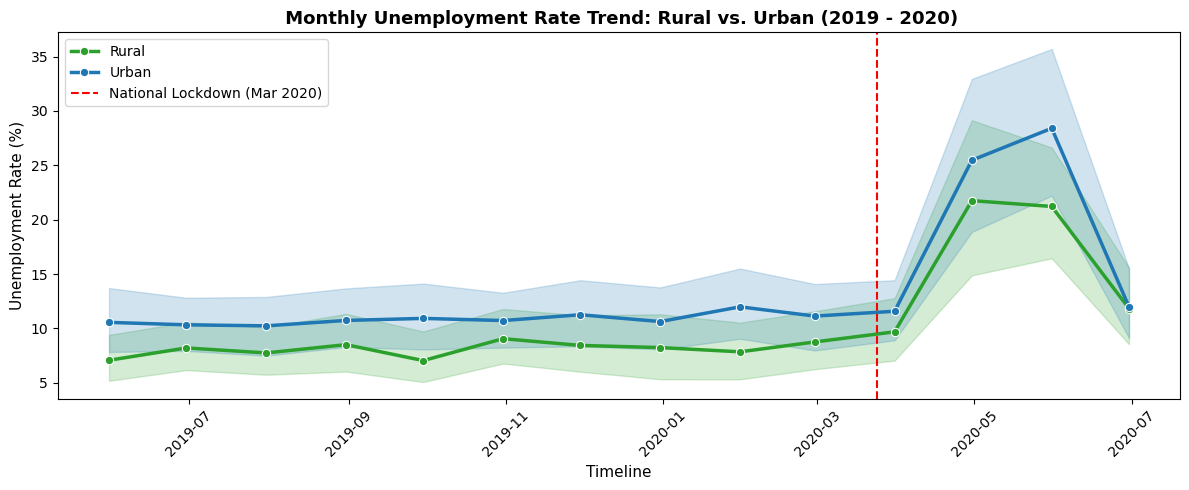

In [7]:
# TIMELINE & COVID-19 IMPACT (RURAL VS. URBAN)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df, 
    x='Date', 
    y='Unemployment_Rate', 
    hue='Area', 
    marker='o', 
    palette=['#2ca02c', '#1f77b4'], 
    linewidth=2.5
)

# Reference Line for Covid-19 Lockdown
plt.axvline(pd.to_datetime('2020-03-24'), color='red', linestyle='--', linewidth=1.5, label='National Lockdown (Mar 2020)')

plt.title(" Monthly Unemployment Rate Trend: Rural vs. Urban (2019 - 2020)", fontsize=13, fontweight='bold')
plt.xlabel("Timeline", fontsize=11)
plt.ylabel("Unemployment Rate (%)", fontsize=11)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\smmblz\AppData\Local\Temp\ipykernel_13544\2474012086.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


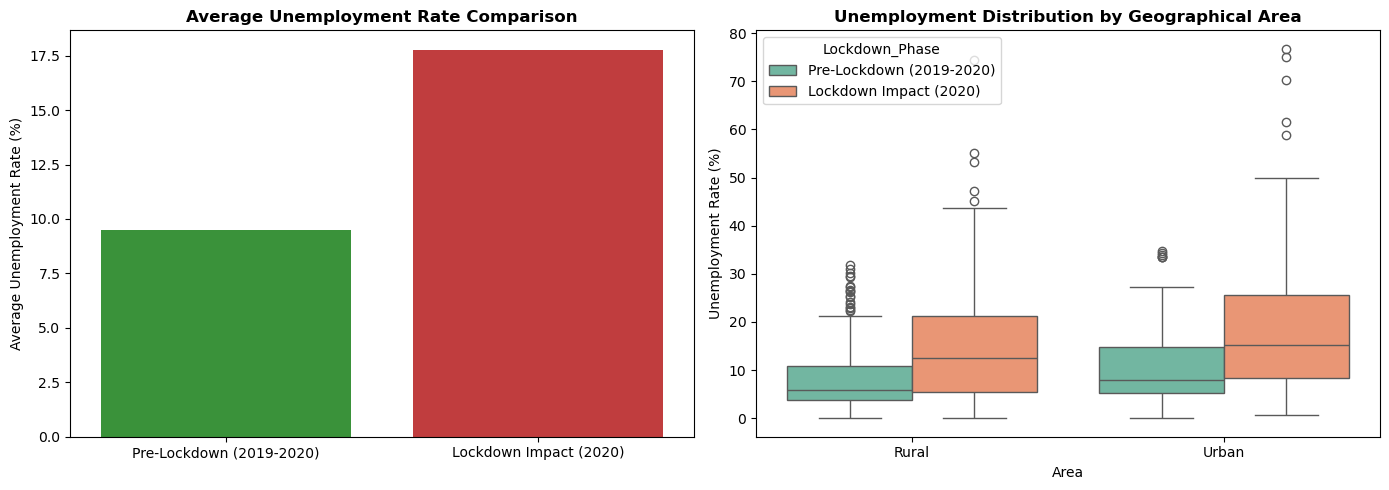

	 	PRE-LOCKDOWN VS LOCKDOWN PHASE SUMMARY TABLE 
                          Unemployment_Rate  Employed_Count  Labour_Participation_Rate
Lockdown_Phase                                                                        
Lockdown Impact (2020)                17.77      6517203.34                      39.33
Pre-Lockdown (2019-2020)               9.51      7466027.87                      43.89


In [8]:
# PRE-LOCKDOWN VS. LOCKDOWN IMPACT COMPARISON

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart: Average Unemployment 
sns.barplot(
    data=df, 
    x='Lockdown_Phase', 
    y='Unemployment_Rate', 
    palette={'Pre-Lockdown (2019-2020)': '#2ca02c', 'Lockdown Impact (2020)': '#d62728'},
    estimator=np.mean,
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Average Unemployment Rate Comparison", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Average Unemployment Rate (%)")
axes[0].set_xlabel("")

# Box Plot: Distribution & Outliers in Urban vs Rural
sns.boxplot(
    data=df, 
    x='Area', 
    y='Unemployment_Rate', 
    hue='Lockdown_Phase', 
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title("Unemployment Distribution by Geographical Area", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Unemployment Rate (%)")
axes[1].set_xlabel("Area")

plt.tight_layout()
plt.show()

# Mean comparison table
print("=" * 85)
print("\t \tPRE-LOCKDOWN VS LOCKDOWN PHASE SUMMARY TABLE ")
print("=" * 85)
phase_summary = df.groupby('Lockdown_Phase')[['Unemployment_Rate', 'Employed_Count', 'Labour_Participation_Rate']].mean().round(2)
print(phase_summary.to_string())
print("=" * 85)

C:\Users\smmblz\AppData\Local\Temp\ipykernel_13544\4142816460.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


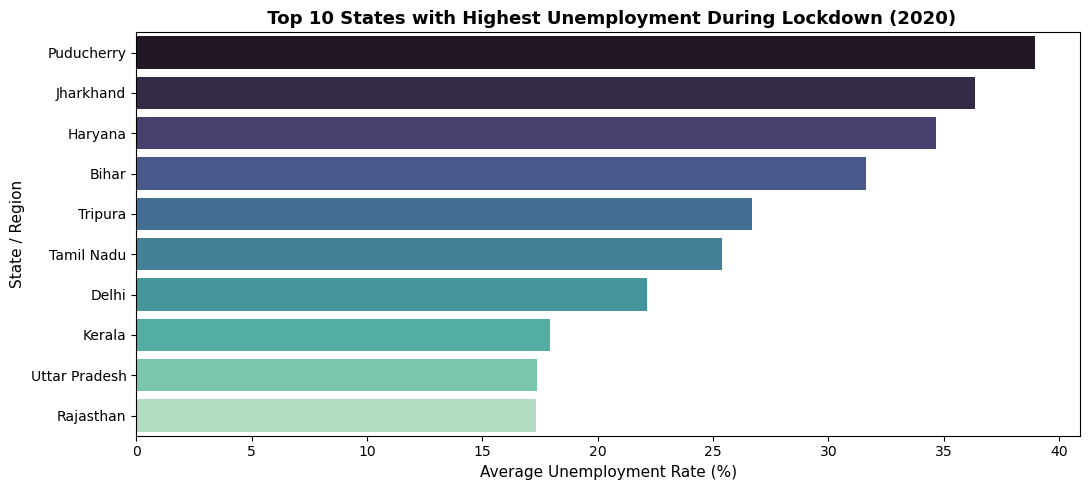

In [9]:
# TOP 10 MOST AFFECTED STATES DURING LOCKDOWN

lockdown_df = df[df['Lockdown_Phase'] == 'Lockdown Impact (2020)']
top_affected_states = lockdown_df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(11, 5))
sns.barplot(
    data=top_affected_states, 
    x='Unemployment_Rate', 
    y='State', 
    palette='mako'
)

plt.title(" Top 10 States with Highest Unemployment During Lockdown (2020)", fontsize=13, fontweight='bold')
plt.xlabel("Average Unemployment Rate (%)", fontsize=11)
plt.ylabel("State / Region", fontsize=11)
plt.tight_layout()
plt.show()

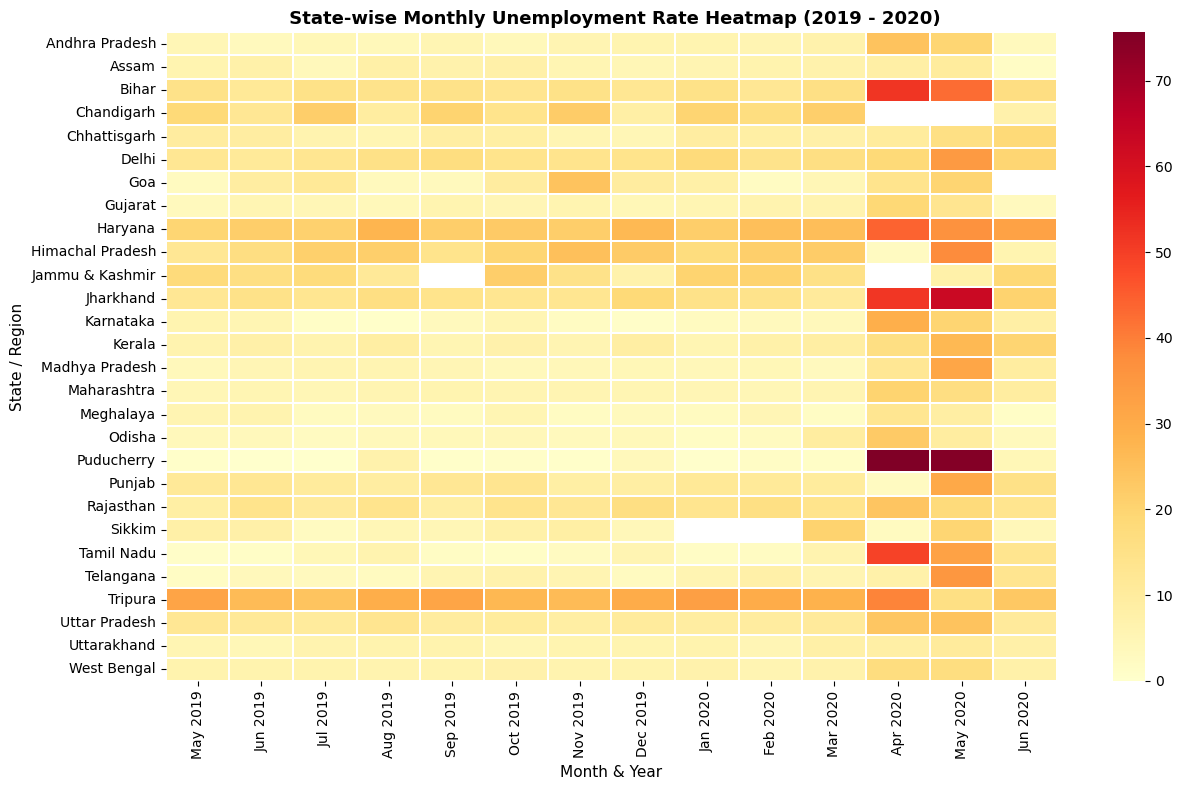

In [10]:
# STATE-WISE UNEMPLOYMENT HEATMAP ACROSS MONTHS

pivot_table = df.pivot_table(
    index='State', 
    columns='Date', 
    values='Unemployment_Rate', 
    aggfunc='mean'
)
pivot_table.columns = pivot_table.columns.strftime('%b %Y')

plt.figure(figsize=(13, 8))
sns.heatmap(pivot_table, cmap='YlOrRd', linewidths=0.3, annot=False)
plt.title(" State-wise Monthly Unemployment Rate Heatmap (2019 - 2020)", fontsize=13, fontweight='bold')
plt.xlabel("Month & Year", fontsize=11)
plt.ylabel("State / Region", fontsize=11)
plt.tight_layout()
plt.show()

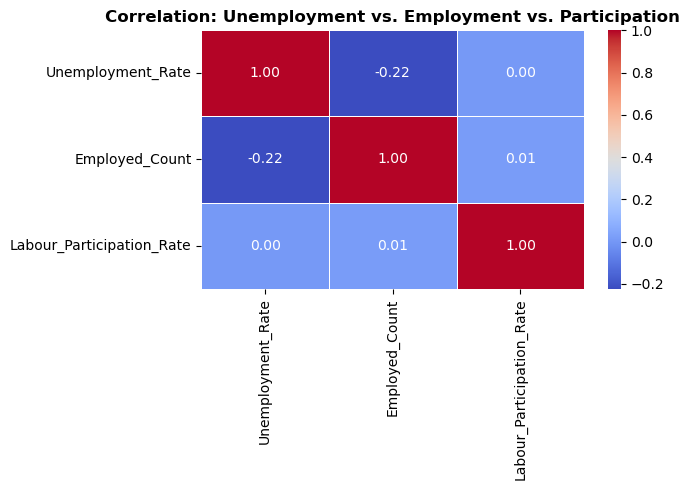

In [11]:
# FEATURE CORRELATION MATRIX

plt.figure(figsize=(7, 5))
numeric_df = df[['Unemployment_Rate', 'Employed_Count', 'Labour_Participation_Rate']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Correlation: Unemployment vs. Employment vs. Participation", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# POLICY INSIGHTS & ECONOMIC TAKEAWAYS

print("=" * 80)
print(" \t\tKEY FINDINGS & POLICY RECOMMENDATIONS ")
print("=" * 80)
print("""
1. Lockdown Surge (April–May 2020):
   - Average unemployment rate jumped from 9.51% (Pre-lockdown) to 17.77% during the lockdown period,
     reaching peaks above 28% across urban centers.

2. Urban vs. Rural Disparity:
   - Urban unemployment increased faster than rural unemployment due to severe disruption in service,
     manufacturing, and informal labor sectors, while agriculture absorbed rural shock.

3. Labour Participation Decline:
   - Labour participation dropped significantly during the pandemic (43.89% to 39.33%), showing
     widespread workforce discouragement.

4. Policy Recommendations:
   - Strengthen urban employment guarantee schemes on the model of rural schemes.
   - Expand targeted direct cash transfers and emergency credit facilities for MSMEs.
""")
print("=" * 80)

 		KEY FINDINGS & POLICY RECOMMENDATIONS 

1. Lockdown Surge (April–May 2020):
   - Average unemployment rate jumped from 9.51% (Pre-lockdown) to 17.77% during the lockdown period,
     reaching peaks above 28% across urban centers.

2. Urban vs. Rural Disparity:
   - Urban unemployment increased faster than rural unemployment due to severe disruption in service,
     manufacturing, and informal labor sectors, while agriculture absorbed rural shock.

3. Labour Participation Decline:
   - Labour participation dropped significantly during the pandemic (43.89% to 39.33%), showing
     widespread workforce discouragement.

4. Policy Recommendations:
   - Strengthen urban employment guarantee schemes on the model of rural schemes.
   - Expand targeted direct cash transfers and emergency credit facilities for MSMEs.

